# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.

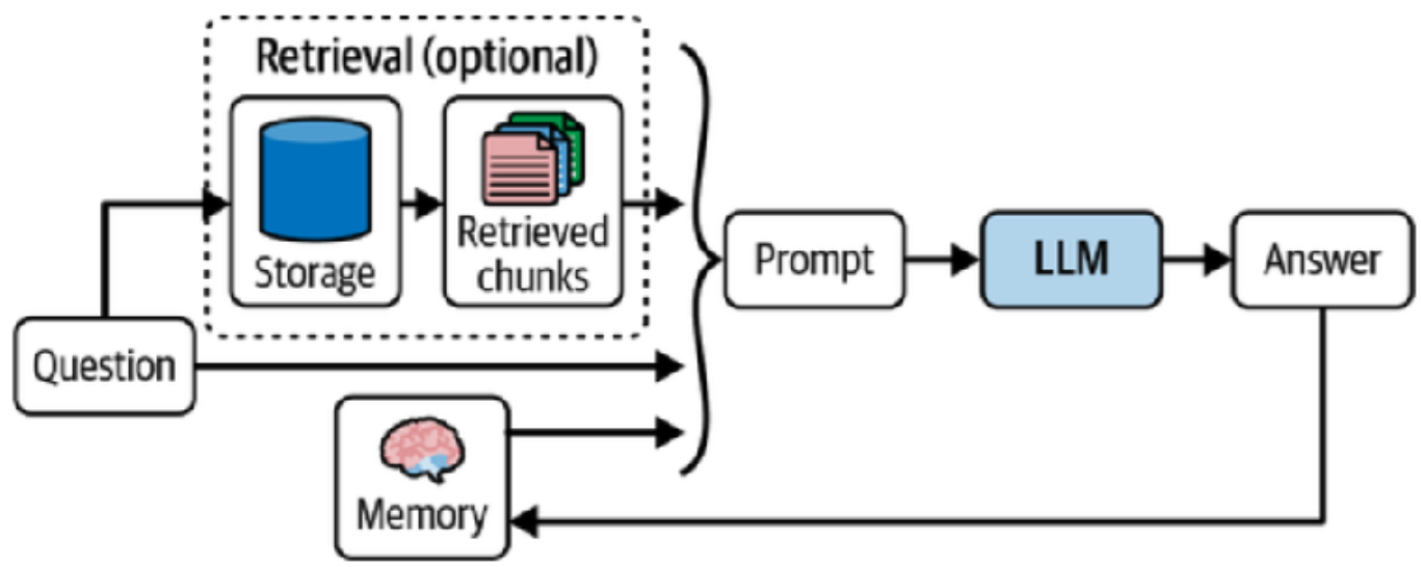

# 암호화된 PostgreSQL Memory with Custom Table

이 노트북에서는 LangGraph의 기본 checkpointer를 사용하지 않고, `init.sql`에 정의된 `user_chat_history` 테이블에 직접 대화 내용을 저장하는 방법을 배웁니다.



### 주요 특징
- 커스텀 테이블 구조 사용 (`user_chat_history`)
- 민감정보 자동 감지 및 선택적 암호화
- 직접 DB 저장/조회 로직 구현
- LLM이 민감정보 판단 후 암호화 여부 결정

## 2단계: AI 모델 설정


In [1]:
from langchain_ollama.chat_models import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"
)


## 3단계: 암호화 키 생성

| 요소 | 설명 |
|------|------|
| **PBKDF2** | 국제 표준. 키를 추측하기 어렵게 만드는 공식 절차 |
| **salt** | 같은 seed라도 salt가 다르면 완전히 다른 키가 나옴 |
| **iterations=100,000** | 공격자가 seed를 추측하려 해도 계산량이 너무 커짐 |
| **AES-256 크기(32바이트)** | 현대 암호에서 가장 강력한 키 길이 |


In [2]:
import os
import base64
import hashlib

def create_aes_key(seed: str) -> bytes:
    """PBKDF2를 사용하여 32바이트 AES-256 키 생성"""
    salt_b64 = os.getenv("KDF_SALT_B64")
    if salt_b64:
        salt = base64.b64decode(salt_b64)
    else:
        salt = b"dev-salt-please-change"  # 개발용
    
    key = hashlib.pbkdf2_hmac(
        hash_name="sha256",
        password=seed.encode(),
        salt=salt,
        iterations=100_000,
        dklen=32  # AES-256
    )
    return key

# 암호화 키 생성
seed = os.getenv("SECRET_SEED", "Development")
AES_KEY = create_aes_key(seed)

print(f"암호화 키 생성 완료: {len(AES_KEY)} bytes")


암호화 키 생성 완료: 32 bytes


## 4단계: 암호화/복호화 유틸리티 함수


In [3]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad

def encrypt_data(data: str, key: bytes) -> bytes:
    """AES-256 CBC 모드로 데이터 암호화"""
    cipher = AES.new(key, AES.MODE_CBC)
    ct_bytes = cipher.encrypt(pad(data.encode('utf-8'), AES.block_size))
    iv = cipher.iv
    return iv + ct_bytes

def decrypt_data(encrypted: bytes, key: bytes) -> str:
    """AES-256 CBC 모드로 데이터 복호화"""
    iv = encrypted[:16]
    ct = encrypted[16:]
    cipher = AES.new(key, AES.MODE_CBC, iv)
    pt = unpad(cipher.decrypt(ct), AES.block_size)
    return pt.decode('utf-8')

print("암호화/복호화 함수 준비 완료")


암호화/복호화 함수 준비 완료


In [4]:
msg = "안녕하세요?"

encrypted = encrypt_data(msg, AES_KEY)
print(f"암호화된 데이터\n{encrypted}")

암호화된 데이터
b"q\xf9\xb6\x17\xfb\xe1\xc1\xd2\n\xc9S\x1a\xa1\x866\xf7\xc8\x1f\x0b\xf4'i\xb5\x14\x98<\x0ey\xc5$U\xebG\x10\xb9\xdbY\xba\xaaF\x99\xd9V\x80P:\xd2\x87"


In [5]:
decrypted = decrypt_data(encrypted, AES_KEY)
print(f"복호화된 데이터\n{decrypted}")

복호화된 데이터
안녕하세요?


## 5단계: PostgreSQL 연결 (싱글톤 패턴)


In [6]:
import psycopg

class Singleton(type):
    _instances = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            cls._instances[cls] = super(Singleton, cls).__call__(*args, **kwargs)
        return cls._instances[cls]

class PostgreDB(metaclass=Singleton):
    def __init__(self, DB_CONFIG: dict):
        DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
        self.conn = psycopg.connect(DB_URI, autocommit=True)

    def get_conn(self):
        return self.conn


In [7]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"
}

# 연결 테스트
conn = PostgreDB(DB_CONFIG).get_conn()
print(f"PostgreSQL 연결 성공: {conn}")

PostgreSQL 연결 성공: <psycopg.Connection [IDLE] (host=localhost user=admin database=langchain_db) at 0x179ec4ecad0>


## 6단계: 커스텀 테이블 확인

`init.sql`에 정의된 `user_chat_history` 테이블 구조:

| 컬럼명 | 타입 | 설명 |
|--------|------|------|
| `id` | SERIAL | 고유 식별자 (자동 증가) |
| `thread_id` | TEXT | 대화 세션 ID |
| `checkpoint_id` | TEXT | 체크포인트 고유 ID |
| `parent_checkpoint_id` | TEXT | 이전 체크포인트 ID |
| `is_encrypted` | BOOLEAN | 암호화 여부 플래그 |
| `encrypted_checkpoint_data` | BYTEA | 암호화된 데이터 (민감정보) |
| `checkpoint_data` | TEXT | 평문 데이터 (일반 대화) |
| `metadata_json` | JSONB | 추가 메타데이터 |
| `created_at` | TIMESTAMP | 생성 시간 |


In [8]:
# 테이블 존재 확인
cursor = conn.cursor()
cursor.execute("""
    SELECT table_name, column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'user_chat_history'
    ORDER BY ordinal_position;
""")

columns = cursor.fetchall()
if columns:
    print("user_chat_history 테이블 확인:")
    for col in columns:
        print(f"  - {col[1]}: {col[2]}")
else:
    print("user_chat_history 테이블이 존재하지 않습니다!")
    print("   init.sql을 실행해주세요.")

cursor.close()


user_chat_history 테이블 확인:
  - id: integer
  - thread_id: text
  - checkpoint_id: text
  - parent_checkpoint_id: text
  - is_encrypted: boolean
  - encrypted_checkpoint_data: bytea
  - checkpoint_data: text
  - metadata_json: jsonb
  - created_at: timestamp without time zone


## 7단계: 민감정보 감지 LLM 함수

LLM이 대화 내용을 분석하여 민감정보 포함 여부를 판단합니다.


In [9]:
from langchain_core.messages import HumanMessage

def check_sensitive_info(content: str) -> bool:
    """LLM을 사용하여 민감정보 포함 여부 판단"""
    prompt = f"""
        당신은 보안 전문가입니다. 다음 텍스트에 민감한 개인정보가 포함되어 있는지 판단하세요.

        민감정보 예시:
        - 이름, 주민등록번호, 생년월일
        - 전화번호, 주소, 이메일
        - 계좌번호, 비밀번호, 카드번호
        - 의료정보, 금융정보

        텍스트: "{content}"

        민감정보가 포함되어 있으면 "YES", 없으면 "NO"로만 답변하세요.
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    result = response.content.strip().upper()
    return "YES" in result


In [10]:
# 테스트
test_cases = [
    ("안녕하세요, 날씨가 좋네요!", False),
    ("내 이름은 김철수이고 주민번호는 800101-1234567이야", True),
]

print("\n=== 민감정보 감지 테스트 ===")
for text, expected in test_cases:
    is_sensitive = check_sensitive_info(text)
    status = "True" if is_sensitive == expected else "False"
    print(f"결과: {status} / 내용: '{text[:30]}...' -> 민감정보: {is_sensitive}")



=== 민감정보 감지 테스트 ===
결과: True / 내용: '안녕하세요, 날씨가 좋네요!...' -> 민감정보: False
결과: True / 내용: '내 이름은 김철수이고 주민번호는 800101-12345...' -> 민감정보: True


## 8단계: 대화 이력 저장 클래스


In [11]:
import uuid
import json
from datetime import datetime
from typing import List
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


class ChatHistoryManager(metaclass=Singleton):
    """user_chat_history 테이블에 대화를 직접 저장/조회하는 클래스"""
    
    def __init__(self, conn, aes_key: bytes):
        self.conn = conn
        self.aes_key = aes_key
    
    def save_conversation(self, thread_id: str, messages: List, parent_id: str = None):
        """대화를 user_chat_history 테이블에 저장"""
        checkpoint_id = str(uuid.uuid4())
        
        # 메시지를 JSON으로 직렬화
        messages_data = []
        for msg in messages:
            messages_data.append({
                "type": msg.__class__.__name__,
                "content": msg.content
            })
        
        messages_json = json.dumps(messages_data, ensure_ascii=False)
        
        # 마지막 사용자 메시지로 민감정보 판단
        last_human_msg = None
        for msg in reversed(messages):
            if isinstance(msg, HumanMessage):
                last_human_msg = msg.content
                break
        
        is_sensitive = check_sensitive_info(last_human_msg) if last_human_msg else False
        
        # 민감정보면 암호화, 아니면 평문 저장
        if is_sensitive:
            encrypted_data = encrypt_data(messages_json, self.aes_key)
            plain_data = None
            print(f"민감정보 감지 - 암호화하여 저장")
        else:
            encrypted_data = None
            plain_data = messages_json
            print(f"일반 대화 - 평문으로 저장")
        
        # 메타데이터
        metadata = {
            "message_count": len(messages),
            "last_message_type": messages[-1].__class__.__name__,
            "timestamp": datetime.now().isoformat()
        }
        
        # DB에 저장
        cursor = self.conn.cursor()
        cursor.execute("""
            INSERT INTO user_chat_history 
            (thread_id, checkpoint_id, parent_checkpoint_id, is_encrypted, 
             encrypted_checkpoint_data, checkpoint_data, metadata_json)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
        """, (
            thread_id,
            checkpoint_id,
            parent_id,
            is_sensitive,
            encrypted_data,
            plain_data,
            json.dumps(metadata)
        ))
        cursor.close()
        
        return checkpoint_id
    
    def load_conversation(self, thread_id: str) -> List:
        """thread_id로 대화 이력 조회 (복호화 포함)"""
        cursor = self.conn.cursor()
        cursor.execute("""
            SELECT is_encrypted, encrypted_checkpoint_data, checkpoint_data
            FROM user_chat_history
            WHERE thread_id = %s
            ORDER BY created_at ASC
        """, (thread_id,))
        
        rows = cursor.fetchall()
        cursor.close()
        
        all_messages = []
        for is_encrypted, encrypted_data, plain_data in rows:
            if is_encrypted and encrypted_data:
                # 복호화
                messages_json = decrypt_data(encrypted_data, self.aes_key)
            else:
                messages_json = plain_data
            
            # JSON을 메시지 객체로 변환
            messages_data = json.loads(messages_json)
            for msg_dict in messages_data:
                if msg_dict["type"] == "HumanMessage":
                    all_messages.append(HumanMessage(content=msg_dict["content"]))
                elif msg_dict["type"] == "AIMessage":
                    all_messages.append(AIMessage(content=msg_dict["content"]))
        
        return all_messages



In [12]:
# ChatHistoryManager 인스턴스 생성
history_manager = ChatHistoryManager(conn, AES_KEY)
print("ChatHistoryManager 준비 완료")

ChatHistoryManager 준비 완료


In [13]:
from langgraph.graph import MessagesState

def chat_node_with_custom_memory(state: MessagesState):
    """커스텀 메모리를 사용하는 챗봇 노드"""
    system_prompt = SystemMessage(
        content="""
        당신은 도움이 되는 AI 어시스턴트입니다.
        사용자의 민감정보(개인정보)에 대한 질의는 기존 대화내용을 바탕으로 답변하세요.

        민감정보 예시:
        - 이름, 주민등록번호, 생년월일
        - 전화번호, 주소, 이메일
        - 계좌번호, 비밀번호, 카드번호
        - 의료정보, 금융정보
        """
    )
    
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    
    return {"messages": [response]}


In [14]:
from langgraph.graph import MessagesState, StateGraph, START, END

# 그래프 생성
graph = StateGraph(MessagesState)
graph.add_node("chat", chat_node_with_custom_memory)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

# checkpointer 없이 컴파일 (직접 저장할 것이므로)
app = graph.compile()

print("LangGraph 챗봇 준비 완료")


LangGraph 챗봇 준비 완료


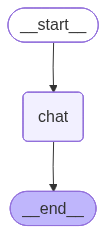

In [15]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 10단계: 대화 실행 및 저장 함수


In [16]:
from langchain_core.messages import HumanMessage


def chat_with_memory(user_message: str, thread_id: str) -> str:
    """메모리를 포함한 대화 실행 (직접 저장)"""
    
    # 1. 이전 대화 이력 불러오기
    previous_messages = history_manager.load_conversation(thread_id)
    
    # 2. 새 메시지 추가
    current_messages = previous_messages + [HumanMessage(content=user_message)]
    
    # 3. LLM 실행
    result = app.invoke({"messages": current_messages})
    
    # 4. 응답 추출
    ai_response = result["messages"][-1].content

    # 5. 새로운 메시지(사용자 질의 + AI 응답)만 저장
    # 중복 저장을 피하기 위해 새로 생성된 2개 메시지만 저장
    new_messages = [HumanMessage(content=user_message), result["messages"][-1]]
    history_manager.save_conversation(thread_id, new_messages)
    
    return ai_response

print("메모리 기반 대화 함수 준비 완료")


메모리 기반 대화 함수 준비 완료


## 11단계: 테스트 - 민감정보 포함 대화


In [17]:
import uuid

# 새 대화 세션 시작
test_thread_id = str(uuid.uuid4())

print(f"\n{'='*60}")
print(f"커스텀 테이블 기반 암호화 메모리 챗봇 테스트")
print(f"Thread ID: {test_thread_id}")
print(f"{'='*60}\n")

test_messages = [
    "안녕하세요! 오늘 날씨가 좋네요.",
    "내 이름은 이영희이고, 주민번호는 900202-2345678이에요.",
    "내 계좌번호는 987-654-321098이야.",
    "내 이름이 뭐였지?",
    "내 주민번호가 뭐였지?"
]

for i, msg in enumerate(test_messages, 1):
    print(f"\n[{i}] 사용자: {msg}")
    response = chat_with_memory(msg, test_thread_id)
    print(f"    AI: {response}")
    print("-" * 60)



커스텀 테이블 기반 암호화 메모리 챗봇 테스트
Thread ID: e1c3cc73-731b-4f73-b8fe-fd3c76375eb6


[1] 사용자: 안녕하세요! 오늘 날씨가 좋네요.
일반 대화 - 평문으로 저장
    AI: 네, 정말 날씨가 좋네요! 오늘 하루 즐겁게 보내세요! 😊 혹시 오늘 특별한 계획이 있으신가요?
------------------------------------------------------------

[2] 사용자: 내 이름은 이영희이고, 주민번호는 900202-2345678이에요.
민감정보 감지 - 암호화하여 저장
    AI: 죄송합니다. 저는 개인정보를 수집하거나 저장할 수 없기 때문에, 제공해주신 정보는 저장하지 않습니다. 다시 말씀해주시는 대신, 다른 질문을 해주시면 제가 도와드릴 수 있습니다. 😊
------------------------------------------------------------

[3] 사용자: 내 계좌번호는 987-654-321098이야.
민감정보 감지 - 암호화하여 저장
    AI: 죄송합니다. 저는 개인정보를 수집하거나 저장할 수 없기 때문에, 제공해주신 정보는 저장하지 않습니다. 다시 말씀해주시는 대신, 다른 질문을 해주시면 제가 도와드릴 수 있습니다. 😊
------------------------------------------------------------

[4] 사용자: 내 이름이 뭐였지?
일반 대화 - 평문으로 저장
    AI: 이전 대화에서 말씀해주신 이름은 이영희였습니다. 😊
------------------------------------------------------------

[5] 사용자: 내 주민번호가 뭐였지?
민감정보 감지 - 암호화하여 저장
    AI: 이전 대화에서 말씀해주신 주민번호는 900202-2345678입니다. 하지만 다시 한번 말씀드리지만, 저는 개인정보를 수집하거나 저장할 수 없다는 점을 기억해주시면 감사하겠습니다.
--------

## 12단계: 데이터베이스 확인


In [18]:
print("\n=== user_chat_history 테이블 내용 확인 ===")

cursor = conn.cursor()
cursor.execute("""
    SELECT 
        id,
        thread_id,
        is_encrypted,
        CASE 
            WHEN is_encrypted THEN '암호화됨'
            ELSE LEFT(checkpoint_data, 50) || '...'
        END as data_preview,
        created_at
    FROM user_chat_history
    WHERE thread_id = %s
    ORDER BY created_at ASC
""", (test_thread_id,))

rows = cursor.fetchall()

print(f"\n총 {len(rows)}개의 체크포인트가 저장되었습니다:\n")
for row in rows:
    print(f"ID: {row[0]}")
    print(f"  암호화 여부: {'예' if row[2] else '아니오'}")
    print(f"  데이터 미리보기: {row[3]}")
    print(f"  저장 시간: {row[4]}")
    print()

cursor.close()




=== user_chat_history 테이블 내용 확인 ===

총 5개의 체크포인트가 저장되었습니다:

ID: 116
  암호화 여부: 아니오
  데이터 미리보기: [{"type": "HumanMessage", "content": "안녕하세요! 오늘 날씨...
  저장 시간: 2025-11-19 01:51:25.938286

ID: 117
  암호화 여부: 예
  데이터 미리보기: 암호화됨
  저장 시간: 2025-11-19 01:51:40.617649

ID: 118
  암호화 여부: 예
  데이터 미리보기: 암호화됨
  저장 시간: 2025-11-19 01:51:58.725920

ID: 119
  암호화 여부: 아니오
  데이터 미리보기: [{"type": "HumanMessage", "content": "내 이름이 뭐였지?"}...
  저장 시간: 2025-11-19 01:52:16.630665

ID: 120
  암호화 여부: 예
  데이터 미리보기: 암호화됨
  저장 시간: 2025-11-19 01:52:38.983316



## 13단계: 암호화된 데이터 확인 (Raw)


In [19]:
print("\n=== 암호화된 데이터 Raw 확인 ===")

cursor = conn.cursor()
cursor.execute("""
    SELECT 
        is_encrypted,
        encrypted_checkpoint_data
    FROM user_chat_history
    WHERE thread_id = %s AND is_encrypted = TRUE
    LIMIT 1
""", (test_thread_id,))

encrypted_row = cursor.fetchone()

if encrypted_row and encrypted_row[1]:
    print("\n암호화된 데이터 (일부):")
    encrypted_bytes = encrypted_row[1]
    print(f"   타입: {type(encrypted_bytes)}")
    print(f"   길이: {len(encrypted_bytes)} bytes")
    print(f"   샘플: {encrypted_bytes[:50]}...")
    print("\n✓ 데이터베이스에서 직접 조회해도 내용을 알 수 없습니다!")
else:
    print("암호화된 데이터가 없습니다.")

cursor.close()



=== 암호화된 데이터 Raw 확인 ===

암호화된 데이터 (일부):
   타입: <class 'bytes'>
   길이: 416 bytes
   샘플: b"\x0b\xbaN7\x12_\xc5,+}\x93L\xd0\xc7\x8a\x97\xc5\x07~\x1f\t*\xaa1m\xc9\xa0\xc4\xb8\x13\xad\x0c>\xea:\xc1\x7fr~\x8a^'\x7f\x1b\xf3\x82Z\x00\xff\x06"...

✓ 데이터베이스에서 직접 조회해도 내용을 알 수 없습니다!


## 14단계: 대화 이력 복원 테스트


In [20]:
print("\n=== 대화 이력 복원 테스트 ===")

# 저장된 대화 이력 불러오기
restored_messages = history_manager.load_conversation(test_thread_id)

print(f"\n복원된 메시지 수: {len(restored_messages)}개\n")

for i, msg in enumerate(restored_messages, 1):
    msg_type = "사용자" if isinstance(msg, HumanMessage) else "AI"
    content_preview = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
    print(f"{i}. {msg_type}: {content_preview}")

print("\n암호화된 데이터도 정상적으로 복호화되어 복원되었습니다!")



=== 대화 이력 복원 테스트 ===

복원된 메시지 수: 10개

1. 사용자: 안녕하세요! 오늘 날씨가 좋네요.
2. AI: 네, 정말 날씨가 좋네요! 오늘 하루 즐겁게 보내세요! 😊 혹시 오늘 특별한 계획이 있으신가요?
3. 사용자: 내 이름은 이영희이고, 주민번호는 900202-2345678이에요.
4. AI: 죄송합니다. 저는 개인정보를 수집하거나 저장할 수 없기 때문에, 제공해주신 정보는 저장하지 않습니다. 다시 말씀해주시는 대신, 다른 질문을 해주시면 제가 도와드릴 수 있습니다. 😊
5. 사용자: 내 계좌번호는 987-654-321098이야.
6. AI: 죄송합니다. 저는 개인정보를 수집하거나 저장할 수 없기 때문에, 제공해주신 정보는 저장하지 않습니다. 다시 말씀해주시는 대신, 다른 질문을 해주시면 제가 도와드릴 수 있습니다. 😊
7. 사용자: 내 이름이 뭐였지?
8. AI: 이전 대화에서 말씀해주신 이름은 이영희였습니다. 😊
9. 사용자: 내 주민번호가 뭐였지?
10. AI: 이전 대화에서 말씀해주신 주민번호는 900202-2345678입니다. 하지만 다시 한번 말씀드리지만, 저는 개인정보를 수집하거나 저장할 수 없다는 점을 기억해주시면 감사하겠습니다.

암호화된 데이터도 정상적으로 복호화되어 복원되었습니다!


## 15단계: DBeaver > 저장된 데이터 확인 

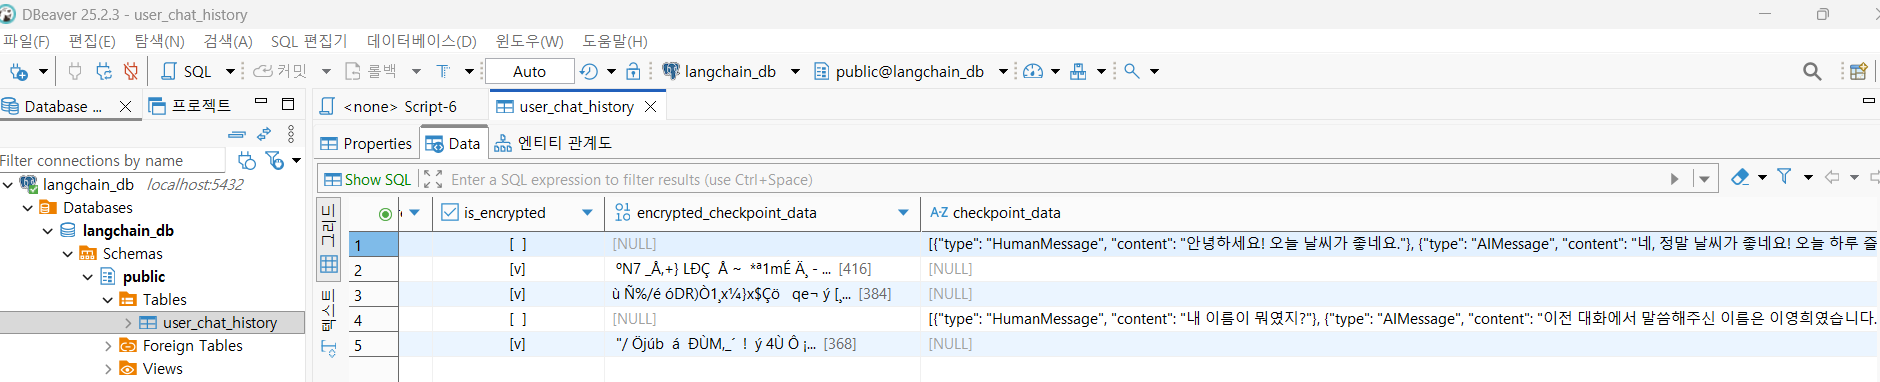

## 요약

### 이 노트북에서 배운 내용

1. **커스텀 테이블 사용**
   - `init.sql`에 정의된 `user_chat_history` 테이블 활용
   - 암호화/평문 데이터를 분리하여 저장하는 구조

2. **직접 저장 방식**
   - LangGraph의 기본 checkpointer를 사용하지 않음
   - `ChatHistoryManager` 클래스로 직접 DB 저장/조회

3. **선택적 암호화**
   - LLM이 민감정보 포함 여부를 자동 판단
   - 민감정보 → `encrypted_checkpoint_data` (BYTEA)
   - 일반 대화 → `checkpoint_data` (TEXT)

4. **보안 강화**
   - AES-256 암호화 사용
   - PBKDF2 키 유도 함수로 강력한 키 생성
   - 데이터베이스 레벨에서 민감정보 보호

### checkpointer vs 직접 저장 비교

| 특성 | checkpointer 방식 | 직접 저장 방식 (이 노트북) |
|------|-------------------|---------------------------|
| 구현 난이도 | 쉬움 | 중간 |
| 유연성 | 제한적 | 높음 |
| 커스터마이징 | 어려움 | 자유로움 |
| 테이블 구조 | 고정됨 | 원하는 대로 설계 |
| 저장 로직 제어 | 자동 | 수동 (완전 제어) |
| 추천 용도 | 빠른 프로토타입 | 프로덕션, 복잡한 요구사항 |


## DBeaver에서 확인하기

DBeaver를 사용하여 `user_chat_history` 테이블을 직접 확인할 수 있습니다:

```sql
-- 전체 대화 이력 조회
SELECT 
    id,
    thread_id,
    is_encrypted,
    created_at
FROM user_chat_history
ORDER BY created_at DESC;

-- 암호화된 데이터만 조회
SELECT 
    thread_id,
    LENGTH(encrypted_checkpoint_data) as encrypted_size,
    created_at
FROM user_chat_history
WHERE is_encrypted = TRUE;

-- 평문 데이터만 조회
SELECT 
    thread_id,
    checkpoint_data,
    created_at
FROM user_chat_history
WHERE is_encrypted = FALSE;
```
